In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

METRICS = ['loss', 'iou', 'precision', 'recall', 'f1']

COLORS = [
    (0.12, 0.47, 0.71),
    (1.00, 0.50, 0.05),
    (0.17, 0.63, 0.17),
    (0.84, 0.15, 0.16),
    (0.58, 0.40, 0.74),
    (0.55, 0.34, 0.29),
    (0.00, 0.62, 0.60),
]

In [14]:
def ShortModelName(model_name):
    partsI = model_name.split('/')
    partsII = partsI[1].split('_')

    arch = partsII[0] if len(partsII) > 1 else "MODEL"
    dataset = (partsI[0].replace("BuildingDataset", "")).upper() if partsI else "DATA"
    loss = partsII[1] if len(partsII) > 2 else "LOSS"

    dim = next((p.replace("dim", "") for p in partsII if p.startswith("dim")), "dim?")
    dim = dim.split('x')[0]

    bs = next((p for p in partsII if p.startswith("bs")), "bs?")

    return f"{arch} | {dataset} | {loss} | {dim} | {bs}"

In [15]:
runs_path = "/home/antoniocorvino/Projects/BuildingsExtraction/runs"

models = [
    "WHUBuildingDataset/unetLL_bce_dim256_n47088_bs8",
    # "InriaBuildingDataset/unet_tiles_BCE_lr0p0001_n44800_dim256x256_bs32",
    # "WHUBuildingDataset/unetLL_focal_dim256_n47088_bs32"
]

In [16]:
runs = {}

for model in models:
    path = f"{runs_path}/{model}/metrics.csv"
    df = pd.read_csv(path)

    # df = df[df['epoch'] <= 60]

    # numeric conversion
    numeric_cols = [
        "train_precision", "train_recall",
        "val_precision", "val_recall"
    ]
    columns_to_smooth=[
            "train_loss", "val_loss",
            "train_iou", "val_iou",
            "train_precision", "val_precision",
            "train_recall", "val_recall"
    ]
    # df = NOTCheating(df, columns_to_smooth=columns_to_smooth, window_size=5, threshold=1)       
    
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # compute F1
    df['train_f1'] = 2 * df['train_precision'] * df['train_recall'] / (
        df['train_precision'] + df['train_recall'] + 1e-8
    )

    df['val_f1'] = 2 * df['val_precision'] * df['val_recall'] / (
        df['val_precision'] + df['val_recall'] + 1e-8
    )

    runs[model] = df

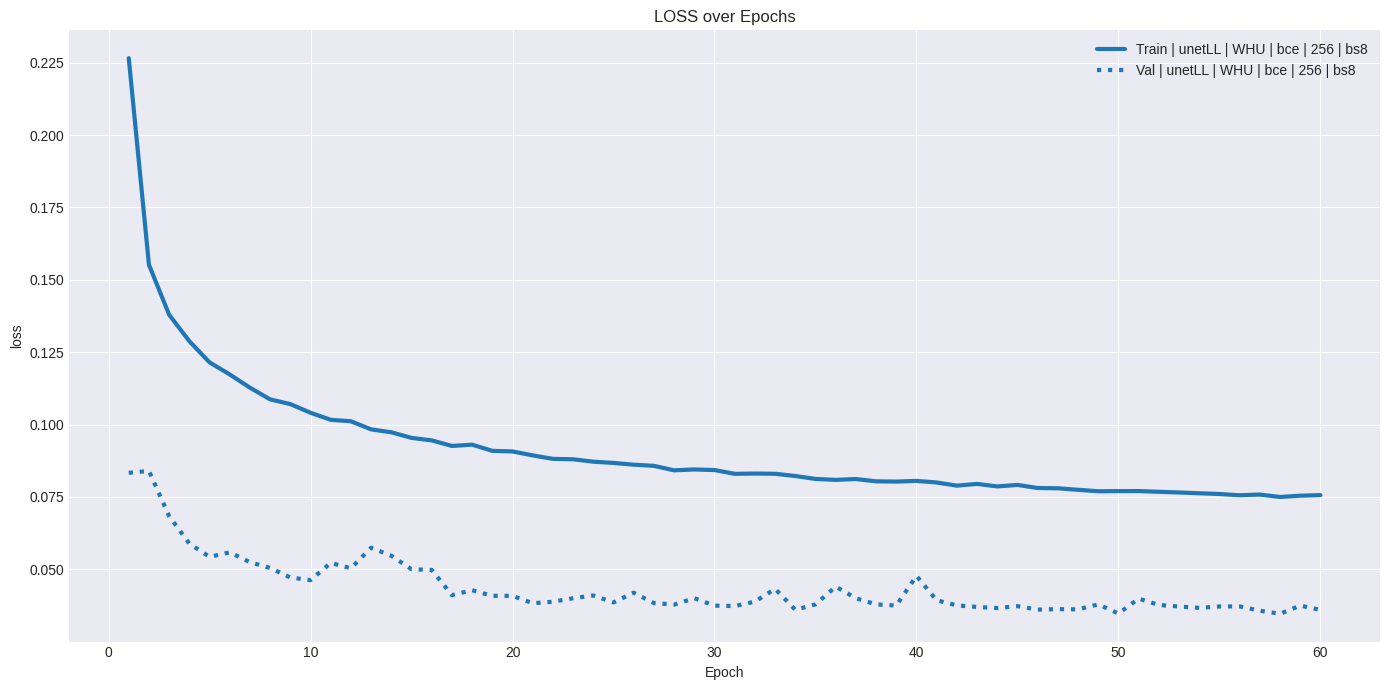

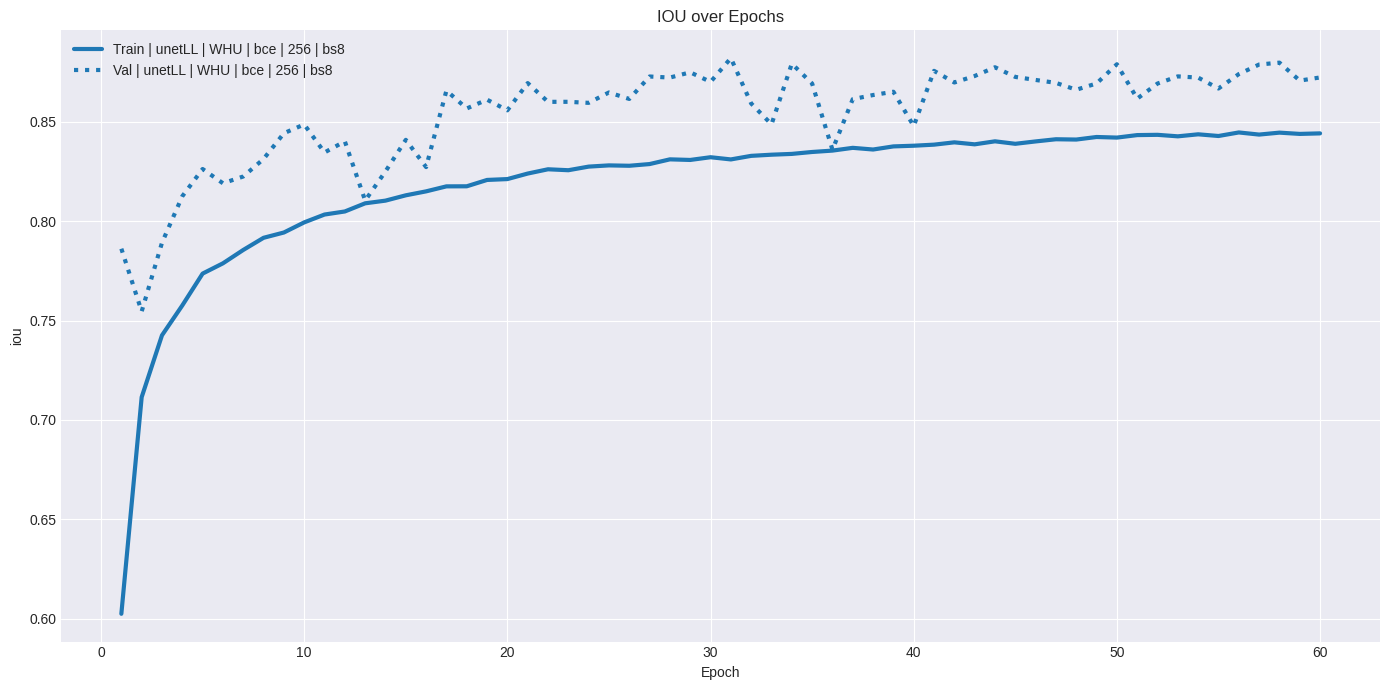

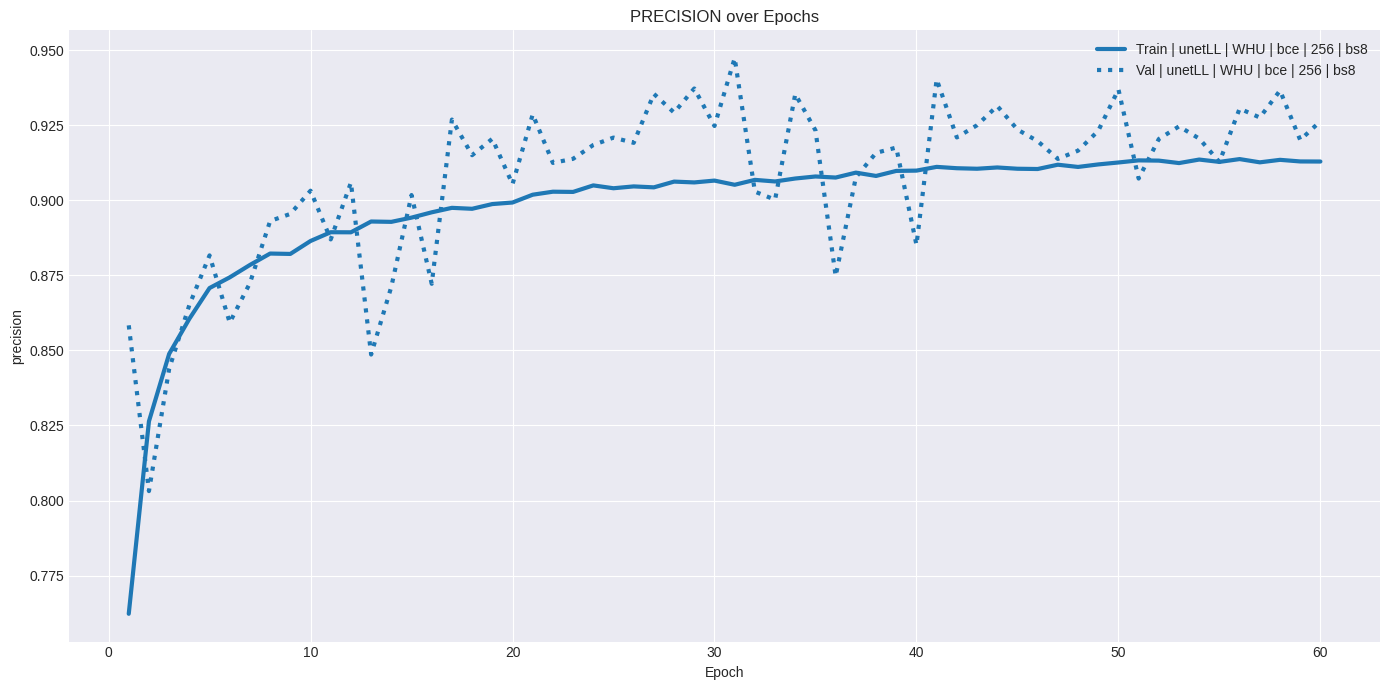

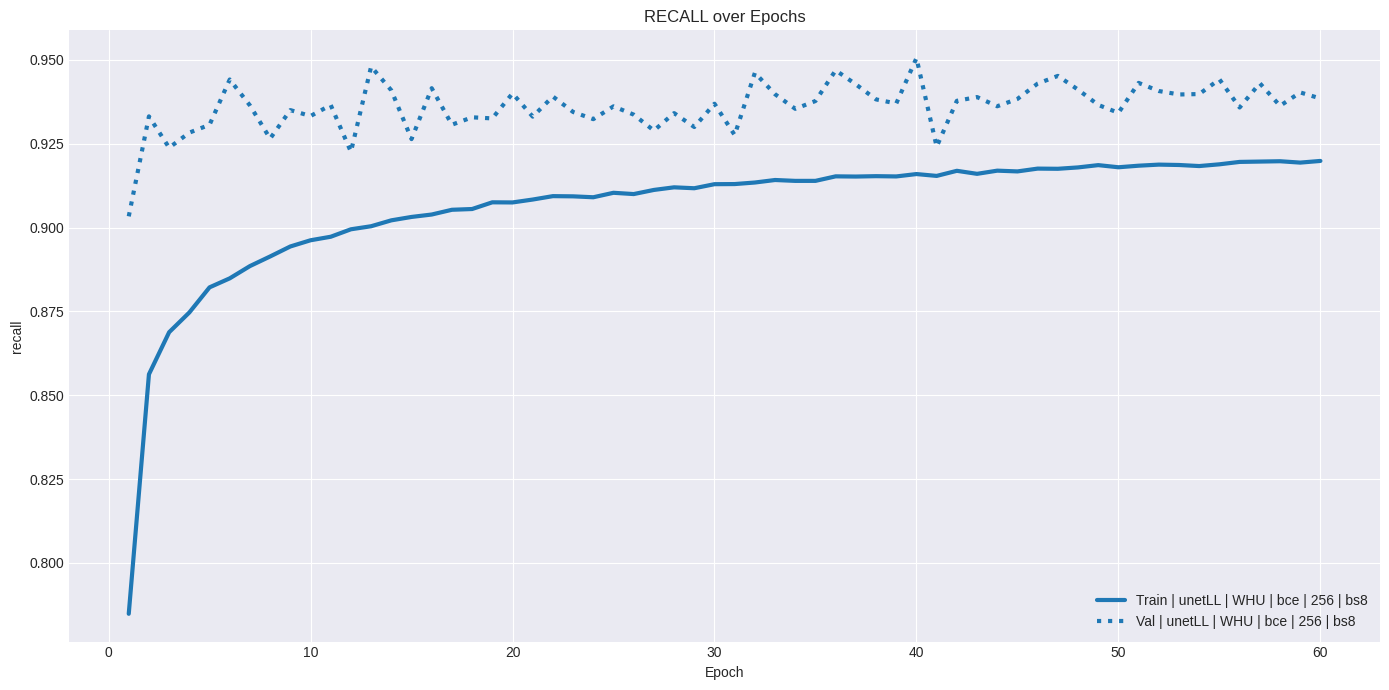

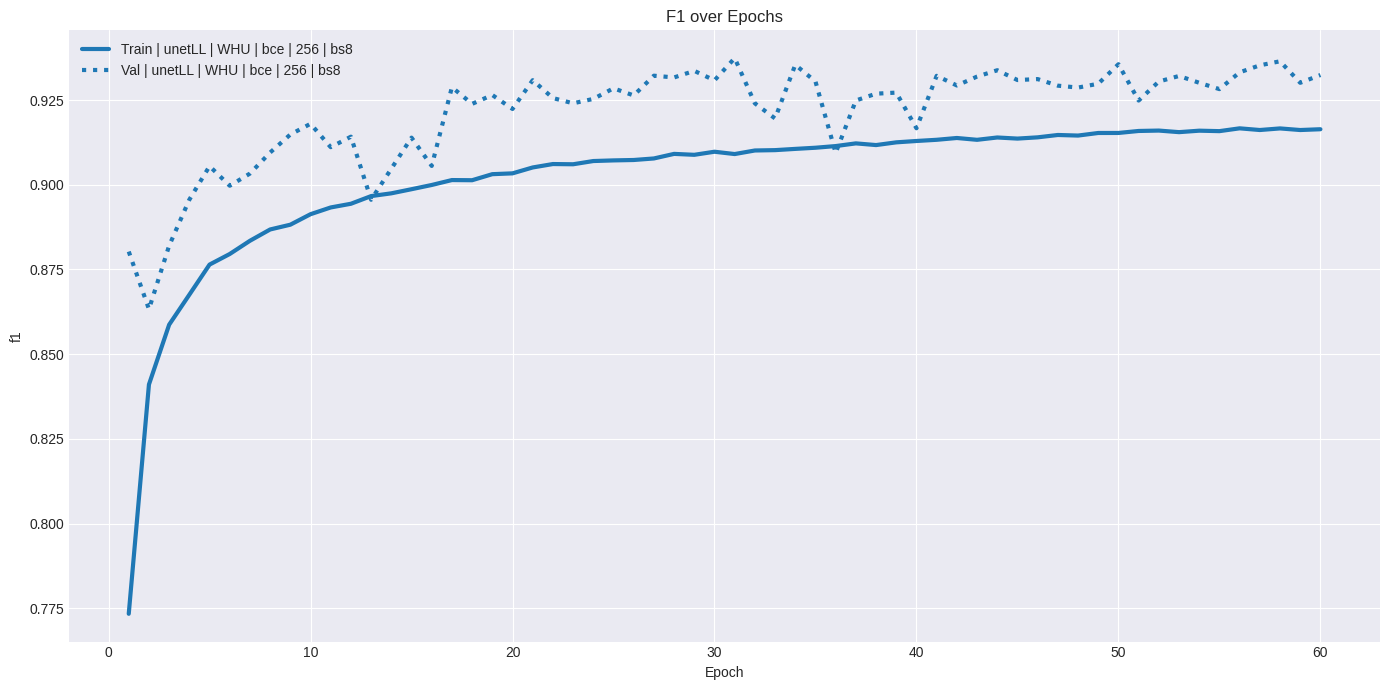

In [18]:

for metric in METRICS:

    plt.figure(figsize=(14,7))

    for idx, model in enumerate(models):

        df = runs[model]
        short = ShortModelName(model)

        plt.plot(
            df["epoch"],
            df[f"train_{metric}"],
            color=COLORS[idx],
            linewidth=3,
            linestyle='-',
            label=f"Train | {short}"
        )

        plt.plot(
            df["epoch"],
            df[f"val_{metric}"],
            color=COLORS[idx],
            linewidth=3,
            linestyle=':',
            label=f"Val | {short}"
        )

    plt.title(f"{metric.upper()} over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"/home/antoniocorvino/Projects/BuildingsExtraction/runs/{model}/{metric}.png")

    plt.show()

In [7]:
for model in models:

    df = runs[model]

    total_seconds = df['epoch_time_sec'].sum()
    hours, rem = divmod(total_seconds, 3600)
    minutes = rem // 60

    print(f"\n--------- {ShortModelName(model)} ---------")
    print(f"Time spent: {int(hours)}:{int(minutes):02d} hours ({df['epoch'].iloc[-1]} epochs)\n")

    print("FINAL VALUES")
    print(f"{'':8s} TRAIN      VALID")
    print(f"Loss    {df['train_loss'].iloc[-1]:.3f}     {df['val_loss'].iloc[-1]:.3f}")
    print(f"IoU     {df['train_iou'].iloc[-1]:.3f}     {df['val_iou'].iloc[-1]:.3f}")
    print(f"Prec    {df['train_precision'].iloc[-1]:.3f}     {df['val_precision'].iloc[-1]:.3f}")
    print(f"Recall  {df['train_recall'].iloc[-1]:.3f}     {df['val_recall'].iloc[-1]:.3f}")
    print(f"F1      {df['train_f1'].iloc[-1]:.3f}     {df['val_f1'].iloc[-1]:.3f}")

KeyError: 'epoch_time_sec'

In [ ]:
for model in models:

    df = runs[model]
    best_epoch = df["val_iou"].idxmax()

    print("\n", ShortModelName(model))
    print("Best epoch:", df.loc[best_epoch, "epoch"])
    print("Best Val IoU:", df.loc[best_epoch, "val_iou"])